# Signal processing

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import datetime as datetime
import os
import scipy
import scipy.signal as signal


In [3]:
import os

# 1. Set the path to the main folder that holds all the date folders
base_path = r"E:\Sun_Observering_Interferometry\radio1\extracted"

# (Optional) Set up a dedicated folder for saving figures 
# You might want to create a 'figures' folder next to 'extracted'
path_save_fig = r"E:\Sun_Observering_Interferometry\radio1\figures" 

# 2. Get the list of items in the path, but ONLY keep them if they are folders
data_folder_list = [folder for folder in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, folder))]

# 3. Count and sort them chronologically
number_folder = len(data_folder_list)
data_folder_list.sort()

# Print the results to verify
print(f"Successfully found {number_folder} date folders.")
print("Folder list:")
for folder in data_folder_list:
    print(folder)

Successfully found 34 date folders.
Folder list:
2025_04_24
2025_05_15
2025_05_19
2025_05_25
2025_05_26
2025_05_27
2025_05_28
2025_05_29
2025_05_30
2025_05_31
2025_06_01
2025_06_02
2025_06_03
2025_06_04
2025_06_05
2025_06_06
2025_06_08
2025_06_09
2025_06_10
2025_06_11
2025_06_12
2025_06_13
2025_06_14
2025_06_15
2025_06_21
2025_06_22
2025_06_23
2025_06_24
2025_06_25
2025_06_26
2025_06_27
2025_06_28
2025_06_29
2025_06_30


In [4]:
def get_folder_file_list(path, folder):

    _file_list = os.listdir(path + '\\' + folder)
    _file_list.sort()

    _number_file = 0
    _file_index = 0

    for file in _file_list:
        if  file < str(f"{folder}_10_00_00_PSD.csv"):
            _file_index += 1
            continue
        elif file > str(f"{folder}_14_00_00_PSD.csv"):
            continue
        
        _number_file += 1

    _frequency =  np.loadtxt(os.path.join(path + '\\' + folder, _file_list[0]), delimiter=',')[:,0]

    _timeStamp_list = np.zeros(_number_file)
    _timeString_list = ["" for i in range(_number_file)]

    for file in _file_list:
        if  file < str(f"{folder}_10_00_00_PSD.csv") or file > str(f"{folder}_14_00_00_PSD.csv"):
            continue

        # Split the string into its components
        components = file.split("_")
        # Extract the date and time components
        date_str = f"{components[0]}-{components[1]}-{components[2]}"
        time_str = f"{components[3]}:{components[4]}:{components[5]}"
        _timeString_list[_file_list.index(file) - _file_index] = time_str
        # Combine the date and time components into a single string
        dateTime_str = f"{date_str} {time_str}"
        
        # Parse the string into a datetime object
        dateTime = datetime.datetime.strptime(dateTime_str, '%Y-%m-%d %H:%M:%S')
        _timeStamp_list[_file_list.index(file) - _file_index] = dateTime.timestamp()

    return _file_list, _frequency, _timeStamp_list, _timeString_list, _number_file

In [5]:
def calculate_power(path, folder, file_list, number_file, Frequency):

    power_list = np.zeros(number_file)
    data_matrix = np.zeros((len(Frequency), number_file))

    _file_index = 0

    for file in file_list:
        if  file < str(f"{folder}_10_00_00_PSD.csv"):
            _file_index += 1

    for file in file_list:

        if  file < str(f"{folder}_10_00_00_PSD.csv") or file > str(f"{folder}_14_00_00_PSD.csv"):
            continue

        data = np.loadtxt(os.path.join(path + "\\" + folder, file), delimiter=',')
        data_matrix[:, file_list.index(file) - _file_index] = data[:, 1]
        power_list[file_list.index(file) - _file_index] = data[:, 1].mean()

    return power_list, data_matrix

In [6]:
def plot_graph(time_list, power_list, date):
    fig, ax = plt.subplots(1, 1, figsize = [24, 8])
    ax.set_title(f'Interferometry 610MHz at Hoa Lac - Ha Noi - {date}', fontsize=20)
    ax.set(xlabel = 'Time(s)', ylabel = 'Signal(dB)')
    ax.grid()
    ax.plot(time_list, power_list, color = 'green', linestyle = '-')

    x = np.arange(0, len(time_list))
    plt.xticks(x[::len(time_list)//25], time_list[::len(time_list)//25], rotation=45, ha='right')
    plt.autoscale()
    plt.show()

    fig.savefig(f"{path_save_fig}\\avg_power\\interferometry_610MHz_{date}.png", dpi=600, bbox_inches='tight')
    return

In [7]:
def remove_spike(x, threshold=3, window_size=11):
    """
    Remove spikes from the x-axis.

    Parameters:
    x (numpy array): The x-axis to remove spikes from.
    threshold (float): The threshold to define spikes. Default value is 3.
    window_size (int): The size of the window to calculate the average. Default value is 11.

    Returns:
    x_smooth (numpy array): The x-axis with spikes removed.
    """
    # Calculate the mean of x
    x_mean = np.mean(x)

    # Calculate the standard deviation of x
    x_std = np.std(x)

    # Finding the indices of spikes
    spike = np.abs(x - x_mean) > threshold * x_std

    # Removing the spike
    x_smooth = np.copy(x)
    x_smooth[spike] = np.mean(x[~spike])

    # Using linear interpolation
    # x_smooth[spike] = np.interp(np.where(spike)[0], np.where(~spike)[0], x[~spike])           # Bad

    # Using Savitzky-Golay filter
    # x_smooth = signal.savgol_filter(x_smooth, window_size, 3)                                 # Dependence on Threshold

    # Using convolution
    x_smooth = np.convolve(x, np.ones(window_size)/window_size, mode='same')                    # Good

    return x_smooth


In [8]:
def plot_histogram(data_matrix, Frequency, time_list, date):
    fig, ax = plt.subplots(1, 1, figsize = [24, 8], layout = 'constrained')
    ax.set_title(f'Interferometry 610MHz at Hoa Lac - Ha Noi - {date}', fontsize=20)
    ax.set_xlabel('Time(hh:mm:ss) UTC+07', fontsize=16)
    ax.set_ylabel('Frequency(MHz)', fontsize=16)
    plt.imshow(data_matrix, cmap = 'inferno', interpolation = 'nearest', aspect = 'auto', origin = 'lower')
    x = np.arange(0, len(time_list))
    plt.xticks(x[::len(time_list)//50], time_list[::len(time_list)//50], rotation=45, ha='right')
    y = np.arange(0, 512)
    plt.yticks(y[::len(Frequency)//8], Frequency[::len(Frequency)//8], rotation=0, ha='right')
    plt.colorbar()
    fig.savefig(f'{path_save_fig}\\histogram\\Interferometry_610MHz_at_Hoa_Lac_Ha_Noi_{date}.png', dpi=600, bbox_inches='tight')
    plt.show()

In [9]:
# mean_power_matrix = np.zeros((1433, number_folder))

# for folder in data_folder_list:
    # number_file = 0

    # file_list, Frequency, timeStamp_list, timeString_list, number_file = get_folder_file_list(path, folder)
    # power_list, data_matrix = calculate_power(path, folder, file_list, number_file, Frequency)

    # remove_spike(power_list, threshold=3, window_size=21)
    # np.savetxt(os.path.join(path, f'mean_power.csv'), np.c_[power_list], delimiter=',', fmt='%f')

    # mean_power_matrix[:, data_folder_list.index(folder)] = power_list

    # Plot the graph and histogram
    # plot_graph(timeString_list, power_list, folder)
    # plot_histogram(data_matrix, Frequency, timeString_list, folder)



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax_graph = plt.subplots(13, 3, figsize=[30, 52], layout='constrained')

counter = 0

for folder in data_folder_list:
    # 1. Changed 'path' to 'base_path' here
    file_list, Frequency, timeStamp_list, timeString_list, number_file = get_folder_file_list(base_path, folder)
    
    # 2. Changed 'path' to 'base_path' here as well
    power_list, data_matrix = calculate_power(base_path, folder, file_list, number_file, Frequency)

    # Truy xuất subplot theo vị trí hàng, cột
    ax = ax_graph[counter // 3][counter % 3]

    ax.set(ylabel='Signal (dB)')
    ax.grid()
    ax.plot(timeString_list, power_list, color='green', linestyle='-')
    ax.set_title(f'{folder}', fontsize=13)

    # Tính toán bước nhảy hợp lý để không bị lỗi chia 0
    total_points = len(timeString_list)
    step = max(1, total_points // 20)

    x = np.arange(0, total_points)
    ax.set_xticks(x[::step])
    ax.set_xticklabels(timeString_list[::step], rotation=45, ha='right')

    counter += 1

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax_graph = plt.subplots(13, 3, figsize=[30, 52], layout='constrained')

counter = 0

for folder in data_folder_list:
    file_list, Frequency, timeStamp_list, timeString_list, number_file = get_folder_file_list(path, folder)
    power_list, data_matrix = calculate_power(path, folder, file_list, number_file, Frequency)

    ax = ax_graph[counter // 3][counter % 3]

    ax.set(ylabel='Signal (dB)')
    im = ax.imshow(data_matrix, cmap='inferno', interpolation='nearest', aspect='auto', origin='lower')
    ax.set_title(f'{folder}', fontsize=13)

    # ----- X-axis: time -----
    total_x = len(timeString_list)
    x_step = max(1, total_x // 20)
    x_ticks = np.arange(0, total_x, x_step)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([timeString_list[i] for i in x_ticks], rotation=45, ha='right')

    # ----- Y-axis: frequency -----
    total_y = len(Frequency)
    y_step = max(1, total_y // 8)
    y_ticks = np.arange(0, total_y, y_step)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([Frequency[i] for i in y_ticks], rotation=0, ha='right')

    counter += 1

plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_29780\1560019392.py:15: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(data_matrix, cmap='inferno', interpolation='nearest', aspect='auto', origin='lower')
C:\Users\admin\AppData\Local\Temp\ipykernel_29780\1560019392.py:15: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(data_matrix, cmap='inferno', interpolation='nearest', aspect='auto', origin='lower')


Skipping folder 2025_04_24: power_list is all zeros or NaN


Skipping folder 2025_05_14: power_list is all zeros or NaN
Skipping folder 2025_05_26: power_list is all zeros or NaN


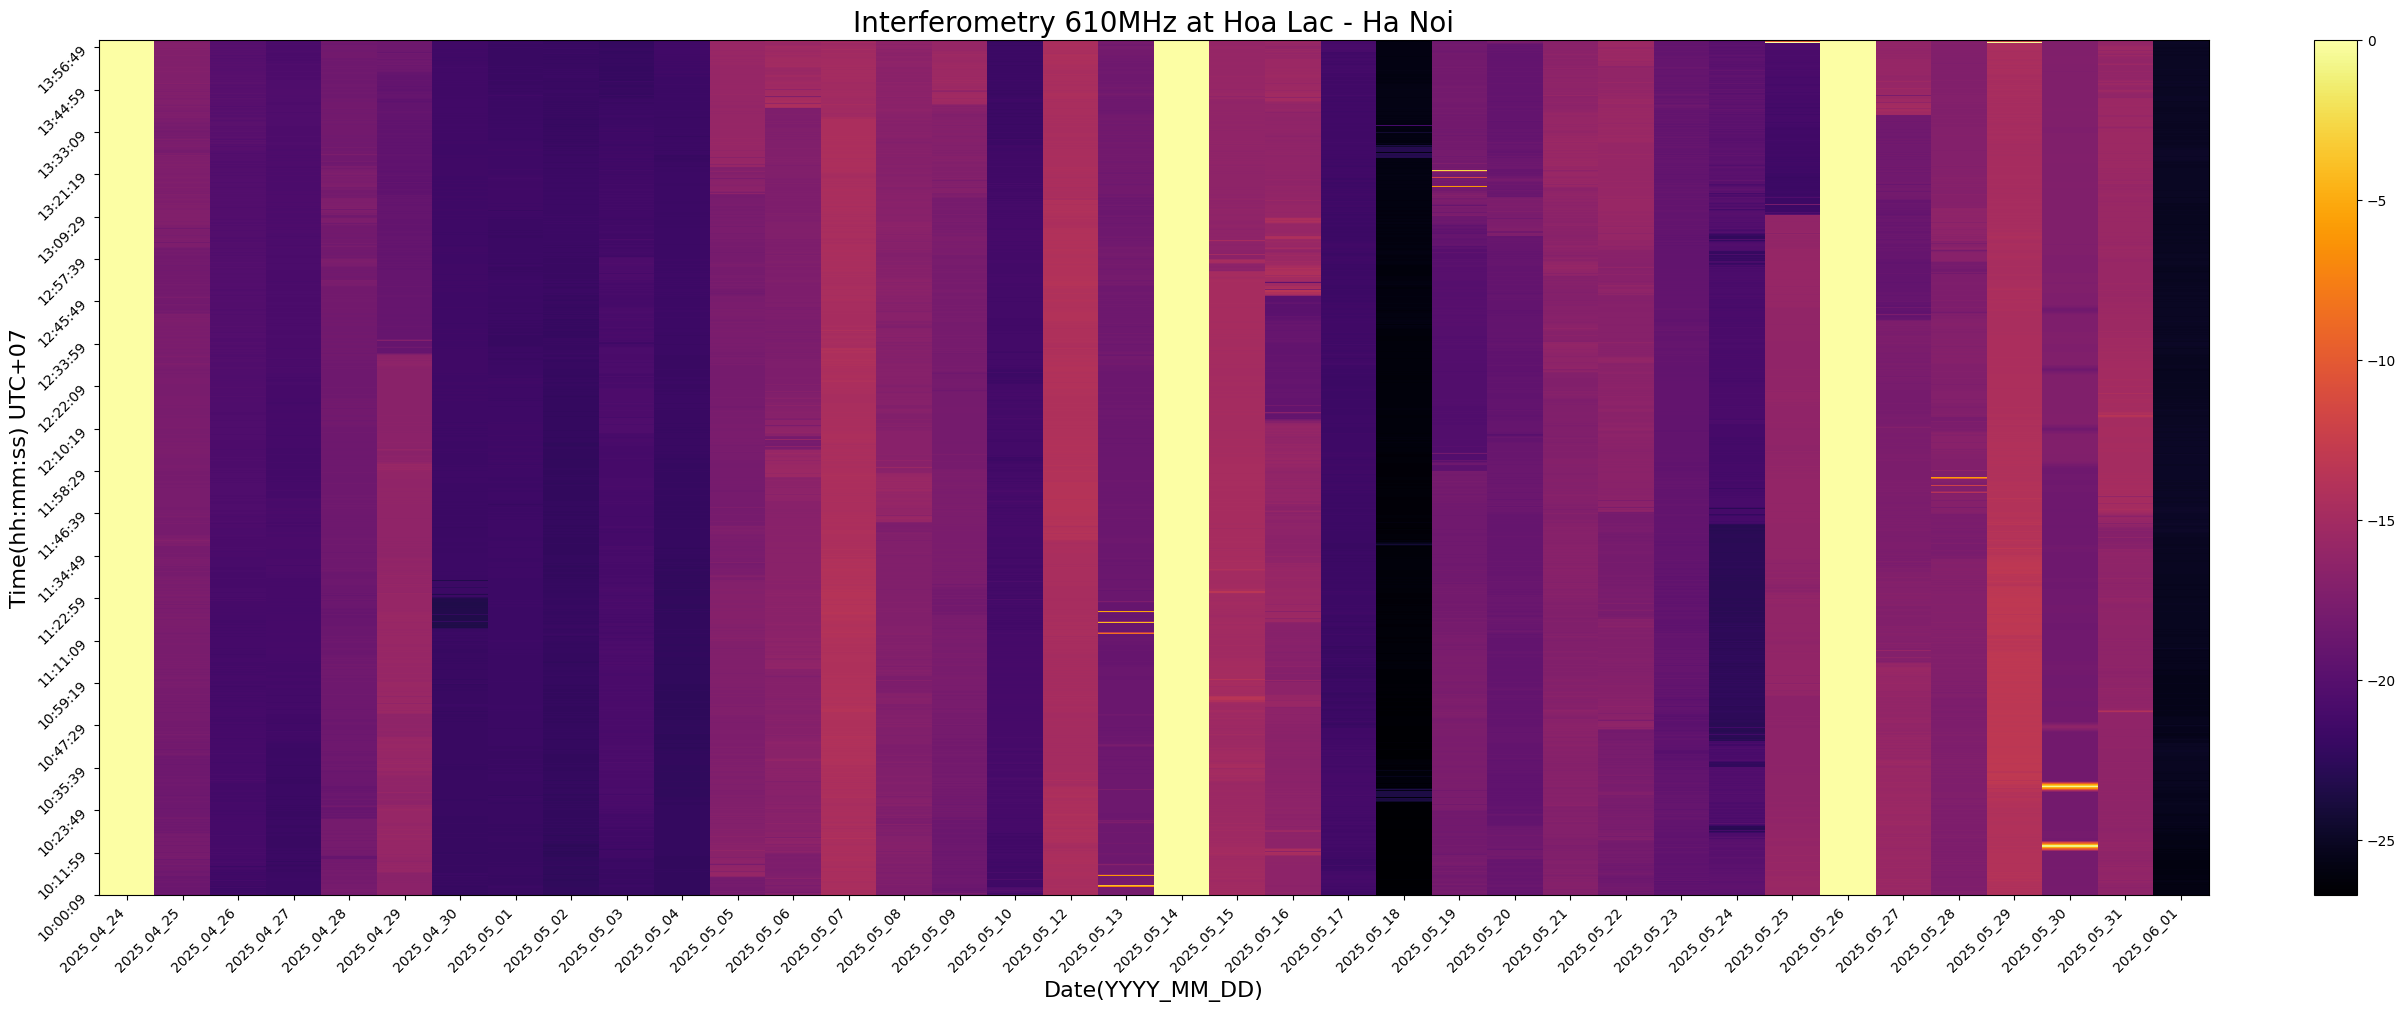

In [ ]:
mean_power_matrix = np.zeros((1433, number_folder))

for folder in data_folder_list:
    number_file = 0

    file_list, Frequency, timeStamp_list, timeString_list, number_file = get_folder_file_list(path, folder)
    power_list, data_matrix = calculate_power(path, folder, file_list, number_file, Frequency)

    # Only assign if power_list is not empty and has the correct shape
    if power_list is not None and not np.all(power_list == 0) and not np.isnan(power_list).all():
        # Resize power_list to fit mean_power_matrix if needed
        if len(power_list) != mean_power_matrix.shape[0]:
            # Interpolate to match the number of rows
            x_old = np.linspace(0, 1, len(power_list))
            x_new = np.linspace(0, 1, mean_power_matrix.shape[0])
            power_list_resized = np.interp(x_new, x_old, power_list)
            mean_power_matrix[:, data_folder_list.index(folder)] = power_list_resized
        else:
            mean_power_matrix[:, data_folder_list.index(folder)] = power_list
    else:
        print(f"Skipping folder {folder}: power_list is all zeros or NaN")

fig, ax = plt.subplots(1, 1, figsize = [24, 10], layout = 'constrained')
ax.set_title(f'Interferometry 610MHz at Hoa Lac - Ha Noi', fontsize=20)
ax.set_xlabel('Date(YYYY_MM_DD)', fontsize=16)
ax.set_ylabel('Time(hh:mm:ss) UTC+07', fontsize=16)
plt.imshow(mean_power_matrix, cmap = 'inferno', interpolation = 'nearest', aspect = 'auto', origin = 'lower')
x = np.arange(0, len(data_folder_list))
plt.xticks(x[::len(data_folder_list)//34], data_folder_list[::len(data_folder_list)//34], rotation=45, ha='right')

# Create a list of time strings from the timestamps from 10_00_00 to 14_00_00
# Use the first and last timestamps in timeStamp_list to generate the range
if len(timeStamp_list) > 0:
    step_seconds = 10  # in seconds
    start_ts = timeStamp_list[0]
    end_ts = timeStamp_list[-1]
    time_list = []
    current_ts = start_ts
    while current_ts <= end_ts:
        time_list.append(datetime.datetime.fromtimestamp(current_ts).strftime('%H:%M:%S'))
        current_ts += step_seconds

    y = np.arange(0, len(time_list))
    plt.yticks(y[::max(1, len(time_list)//20)], time_list[::max(1, len(time_list)//20)], rotation=45, ha='right')
plt.colorbar()
plt.show()


ValueError: slice step cannot be zero

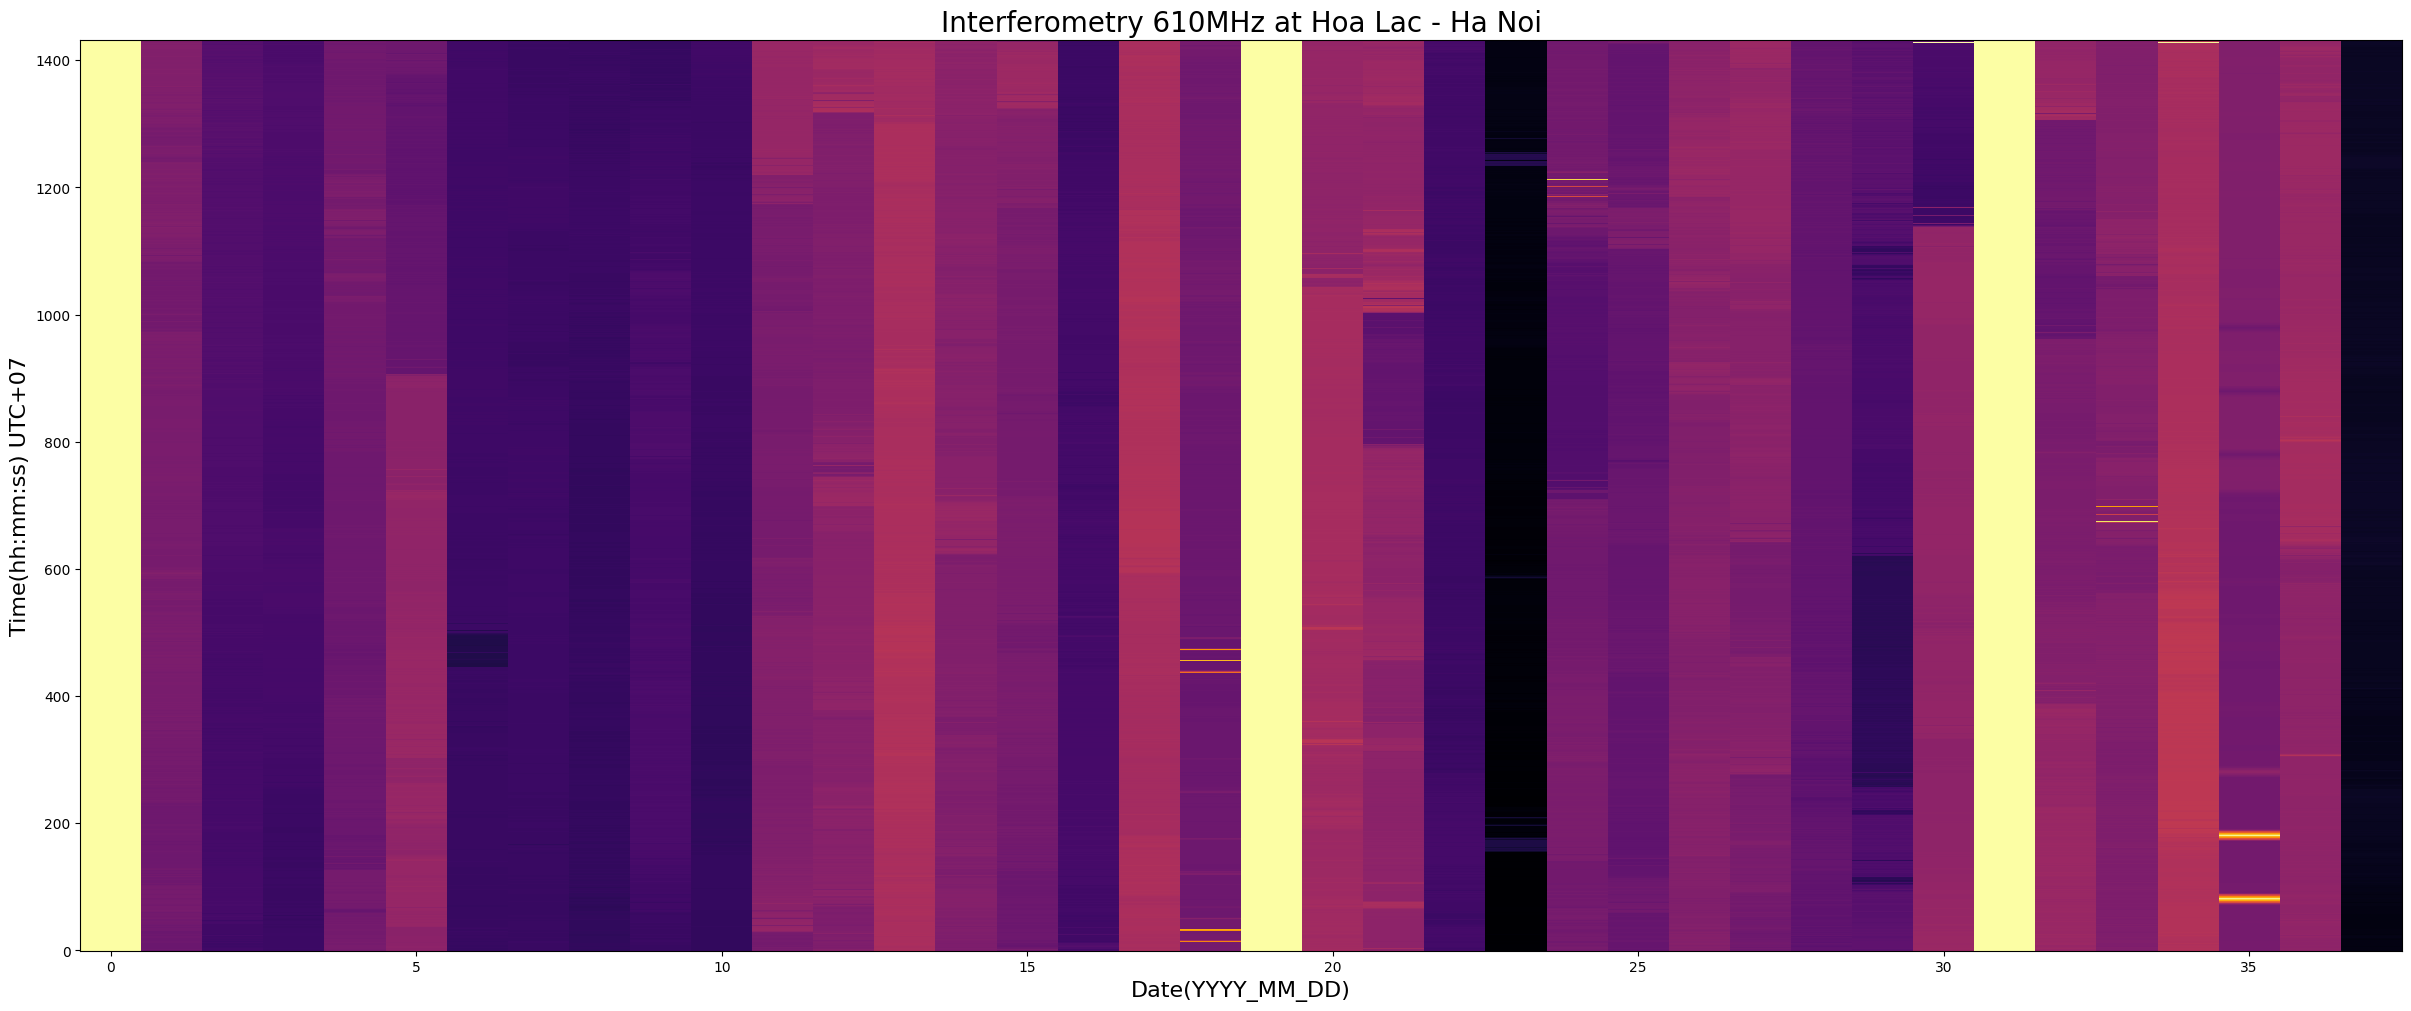

In [ ]:

fig, ax = plt.subplots(1, 1, figsize = [24, 10], layout = 'constrained')
ax.set_title(f'Interferometry 610MHz at Hoa Lac - Ha Noi', fontsize=20)
ax.set_xlabel('Date(YYYY_MM_DD)', fontsize=16)
ax.set_ylabel('Time(hh:mm:ss) UTC+07', fontsize=16)
plt.imshow(mean_power_matrix, cmap = 'inferno', interpolation = 'nearest', aspect = 'auto', origin = 'lower')
x = np.arange(0, len(data_folder_list))
plt.xticks(x[::len(data_folder_list)//39], data_folder_list[::len(data_folder_list)//39], rotation=45, ha='right')

# Create a list of time strings from the timestamps from 10_00_00 to 14_00_00
# Use the first and last timestamps in timeStamp_list to generate the range
step_seconds = 10  # in seconds
start_ts = timeStamp_list[0]
end_ts = timeStamp_list[-1]
time_list = []
current_ts = start_ts
while current_ts <= end_ts:
    time_list.append(datetime.datetime.fromtimestamp(current_ts).strftime('%H:%M:%S'))
    current_ts += step_seconds

y = np.arange(0, len(time_list))
plt.yticks(y[::len(time_list)//20], time_list[::len(time_list)//20], rotation=45, ha='right')
plt.colorbar()
plt.show()
